---

**LOGISTIC REGRESSION**
- Data Exploration
- Data Preprocessing
- Model Building
- Model Evaluation
- Interpretation
- Deployment with Streamlit

In [1]:
# Imports & constants
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import joblib

# Constants
# Detect root workspace where Titanic files live
cwd = Path.cwd()
if (cwd / 'Titanic_train.csv').exists():
    BASE = cwd
elif (cwd.parent / 'Titanic_train.csv').exists():
    BASE = cwd.parent
elif (cwd.parents[1] / 'Titanic_train.csv').exists():
    BASE = cwd.parents[1]
else:
    BASE = cwd

TRAIN_CSV = BASE / 'Titanic_train.csv'
TEST_CSV = BASE / 'Titanic_test.csv'
OUT_DIR = BASE / 'eda' / 'notebook_artifacts'
RANDOM_STATE = 42
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Notebook constants set. Train CSV:', TRAIN_CSV)


Notebook constants set. Train CSV: c:\Users\spanda4\ExcelrAssign\Logistic Regression\Titanic_train.csv


In [2]:
# Load datasets
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV) if TEST_CSV.exists() else None
print('Train shape:', train.shape)
print('Test shape:', None if test is None else test.shape)
train.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Quick inspection: types, summary statistics, missing values


In [3]:
# Quick inspection
train.info()
train.describe(include='all').T
print('\nMissing values:')
print(train.isnull().sum().sort_values(ascending=False))

# Value counts for key columns
for col in ['Survived','Pclass','Sex','Embarked']:
    if col in train.columns:
        print(f"\nValue counts for {col}:\n", train[col].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0

## EDA visualizations
The plots below visualize distributions and relationships (saved to artifacts).

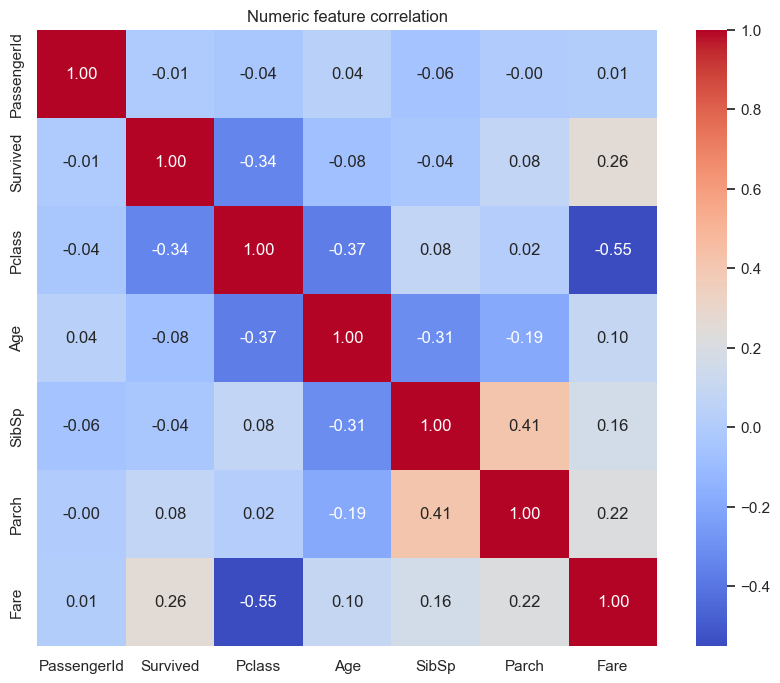

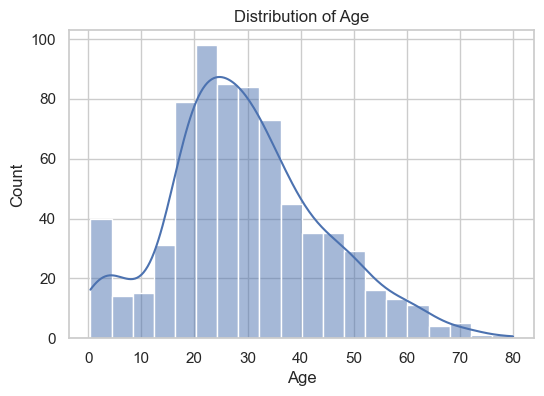

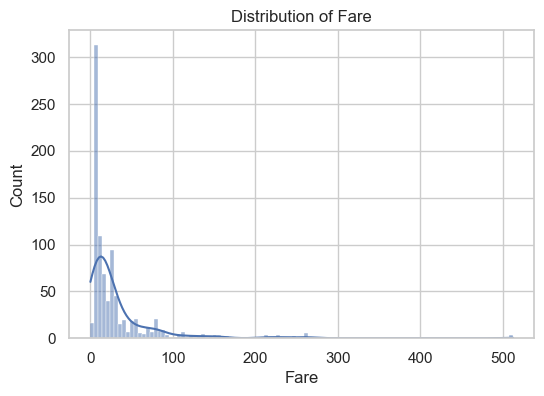

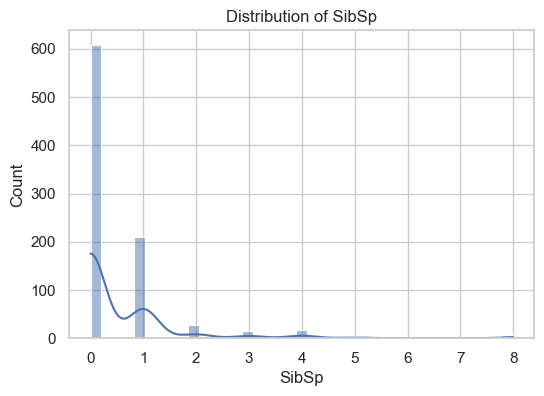

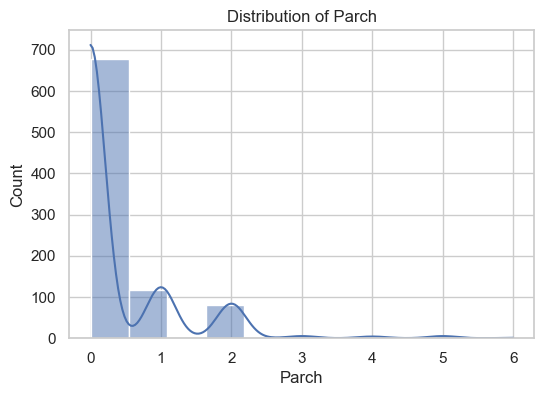

In [4]:
# Basic EDA plots and save to OUT_DIR
sns.set(style='whitegrid')
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric feature correlation')
plt.savefig(OUT_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Histograms for selected cols
for col in ['Age','Fare','SibSp','Parch']:
    if col in train.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(train[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.savefig(OUT_DIR / f'hist_{col}.png', bbox_inches='tight')
        plt.show()

## Cleaning & simple imputation
We impute `Age` with median for now, fill `Embarked` with mode, and `Fare` with median. More advanced imputation can be added later.

In [5]:
train_clean = train.copy()
train_clean['Age'] = train_clean['Age'].fillna(train_clean['Age'].median())
train_clean['Embarked'] = train_clean['Embarked'].fillna(train_clean['Embarked'].mode()[0])
train_clean['Fare'] = train_clean['Fare'].fillna(train_clean['Fare'].median())
print('Nulls after basic imputation:')
print(train_clean.isnull().sum().sort_values(ascending=False).head(20))
train_clean.head()

Nulls after basic imputation:
Cabin          687
PassengerId      0
Pclass           0
Survived         0
Name             0
Sex              0
SibSp            0
Age              0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Encoding and feature engineering
Encode categorical variables and extract useful features (titles, family size, is alone, deck).

In [6]:
# Encoding & feature engineering
train_enc = train_clean.copy()
# Sex numeric
train_enc['Sex'] = train_enc['Sex'].map({'male':0,'female':1})
# Titles
def extract_title(name):
    m = re.search(r",\s*([^,.]+)\.", name)
    return m.group(1).strip() if m else 'Unknown'
train_enc['Title'] = train_enc['Name'].apply(extract_title)
train_enc['Title'] = train_enc['Title'].replace(['Mlle','Ms'],'Miss').replace(['Mme'],'Mrs')
rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
train_enc['Title'] = train_enc['Title'].apply(lambda x: 'Rare' if x in rare_titles else x)
# Cabin deck (first letter)
train_enc['Deck'] = train_enc['Cabin'].fillna('M').apply(lambda x: str(x)[0] if x!='M' else 'M')
# Family features
train_enc['FamilySize'] = train_enc['SibSp'] + train_enc['Parch'] + 1
train_enc['IsAlone'] = (train_enc['FamilySize'] == 1).astype(int)
# Age bin
train_enc['AgeBin'] = pd.cut(train_enc['Age'], bins=[0,12,20,40,60,100], labels=False)
# One-hot for selected categoricals (Title, Deck, Embarked)
train_enc = pd.get_dummies(train_enc, columns=['Title','Deck','Embarked'], drop_first=True)
train_enc.head()[['Sex','Title_Mr' if 'Title_Mr' in train_enc.columns else 'Title_Miss' , 'FamilySize','IsAlone'] if any(c.startswith('Title_') for c in train_enc.columns) else ['Sex','FamilySize','IsAlone']]

,Sex,Title_Mr,FamilySize,IsAlone
0,0,True,2,0
1,1,False,2,0
2,1,False,1,1
3,1,False,2,0
4,0,True,1,1


## Feature selection and correlation check
Select a compact set of features for modeling and inspect correlations to avoid strong multicollinearity.

Using features (sample): ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Sex', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_the Countess', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_M', 'Deck_T']


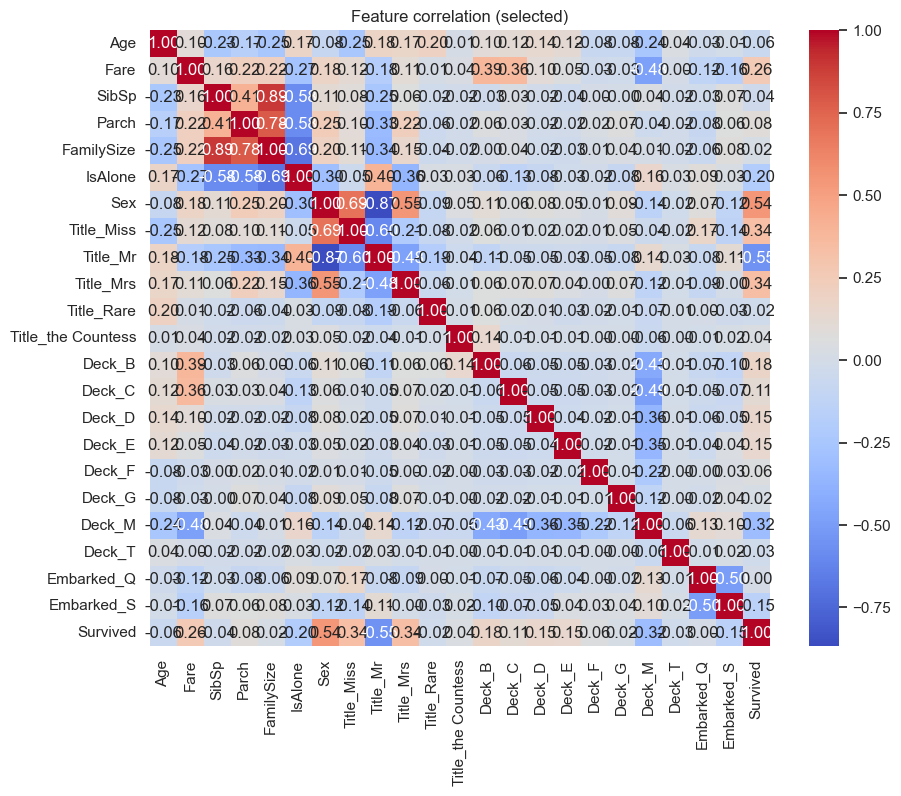

In [7]:
# Build feature list
base_feats = ['Age','Fare','SibSp','Parch','FamilySize','IsAlone','Sex']
# add one-hot columns we created for Title/Deck/Embarked (prefixes)
extra = [c for c in train_enc.columns if c.startswith('Title_') or c.startswith('Deck_') or c.startswith('Embarked_')]
features = base_feats + extra
features = [f for f in features if f in train_enc.columns]
print('Using features (sample):', features[:20])
corr = train_enc[[c for c in features if train_enc[c].dtype != 'object'] + ['Survived']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlation (selected)')
plt.savefig(OUT_DIR / 'selected_feature_correlation.png', bbox_inches='tight')
plt.show()

## Train / validation split and scaling
Prepare the train/validation split and scale numeric features.

In [8]:
X = train_enc[features].copy()
y = train_enc['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
num_feats = ['Age','Fare','SibSp','Parch','FamilySize']
scaler = StandardScaler()
X_train[num_feats] = scaler.fit_transform(X_train[num_feats])
X_val[num_feats] = scaler.transform(X_val[num_feats])
print('Train/val sizes:', X_train.shape, X_val.shape)

Train/val sizes: (712, 22) (179, 22)


## Model training: Logistic Regression and Random Forest (baseline)
Train simple baseline models and compare.

In [9]:
models = {
    'logreg': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'rf': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
}
fitted = {}
for name, m in models.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    t1 = time.time()
    fitted[name] = m
    print(f'Trained {name} in {t1-t0:.2f}s')

Trained logreg in 0.02s
Trained rf in 0.30s


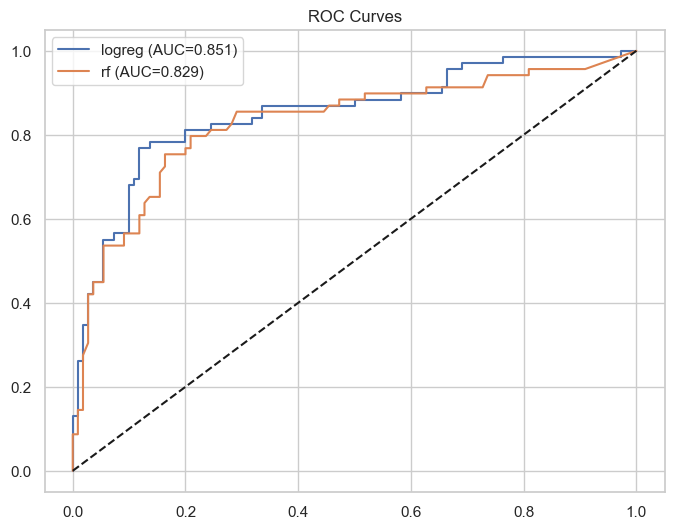

,accuracy,precision,recall,f1,roc_auc
model,,,,,
logreg,0.826816,0.796875,0.739130,0.766917,0.850988
rf,0.770950,0.725806,0.652174,0.687023,0.828920


In [10]:
# Model Evaluation
results = []
plt.figure(figsize=(8,6))
for name, mod in fitted.items():
    preds = mod.predict(X_val)
    probs = mod.predict_proba(X_val)[:,1] if hasattr(mod, 'predict_proba') else mod.predict(X_val)
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds)
    rec = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    roc = roc_auc_score(y_val, probs)
    results.append({'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc})
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title('ROC Curves')
plt.savefig(OUT_DIR / 'roc_curves.png', bbox_inches='tight')
plt.show()
res_df = pd.DataFrame(results).set_index('model')
res_df

In [11]:
param_grid = {'C':[0.01,0.1,1,10,100]}
grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
best_logreg = grid.best_estimator_
probs = best_logreg.predict_proba(X_val)[:,1]
print('Validation ROC-AUC (best_logreg):', roc_auc_score(y_val, probs))

Best params: {'C': 0.1}
Validation ROC-AUC (best_logreg): 0.8459815546772069


## Save artifacts (model & scaler)
Persist the best model and scaler for deployment and the Streamlit app.

In [12]:
artifacts = OUT_DIR / 'artifacts'
artifacts.mkdir(parents=True, exist_ok=True)
joblib.dump(best_logreg, artifacts / 'best_logreg.joblib')
joblib.dump(scaler, artifacts / 'scaler.joblib')
print('Saved artifacts to', artifacts)

Saved artifacts to c:\Users\spanda4\ExcelrAssign\Logistic Regression\eda\notebook_artifacts\artifacts


## Interpretation
Load the saved model and run predictions on new samples or rows from the validation set.

In [13]:
# Load artifacts and predict on a few validation rows
loaded = joblib.load(artifacts / 'best_logreg.joblib')
loaded_scaler = joblib.load(artifacts / 'scaler.joblib')
sample = X_val.sample(3, random_state=RANDOM_STATE).copy()
sample[num_feats] = loaded_scaler.transform(sample[num_feats])
print('Predictions:', loaded.predict(sample))
print('Probabilities:', loaded.predict_proba(sample)[:,1])

Predictions: [0 1 1]
Probabilities: [0.21099362 0.6211458  0.74478501]


---
## Final notes and next steps
- This notebook provides a reproducible pipeline for EDA, modeling, and saving artifacts.
- To deploy with Streamlit, point the app to `artifacts/best_logreg.joblib` and `artifacts/scaler.joblib`.
- Improvements: smarter `Age` imputation, feature interactions, cross-validated model ensembling, and SHAP explainability.



### Answers

1. **Precision vs Recall**:

- **Precision**: Proportion of positive predictions that are correct. Formula: $\text{Precision}=\frac{TP}{TP+FP}$. High precision means few false positives.

- **Recall** (Sensitivity): Proportion of actual positives correctly identified. Formula: $\text{Recall}=\frac{TP}{TP+FN}$. High recall means few false negatives.

2. **Cross-validation and its importance**:

- **Cross-validation**: A technique that splits data into multiple train/validation folds (e.g., k-fold) and evaluates model performance across these folds.

- **Why important**: It provides a more reliable estimate of generalization performance, helps detect overfitting, aids hyperparameter tuning (e.g., via GridSearchCV), and uses data efficiently by validating on multiple splits.